In [2]:
import numpy as np

Python: Max=164966, Min=1, Mean=10107.283989709083, Median=9508.5, Std=6685.772333613203
Rust: Max=164987, Min=1, Mean=10107.283989709083, Median=9494.0, Std=6519.527963367029


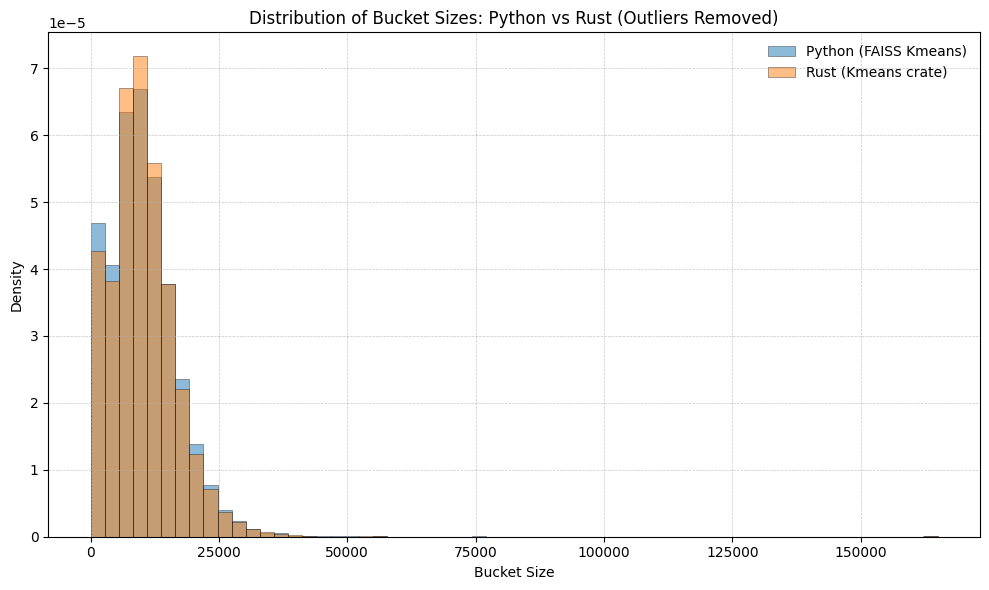

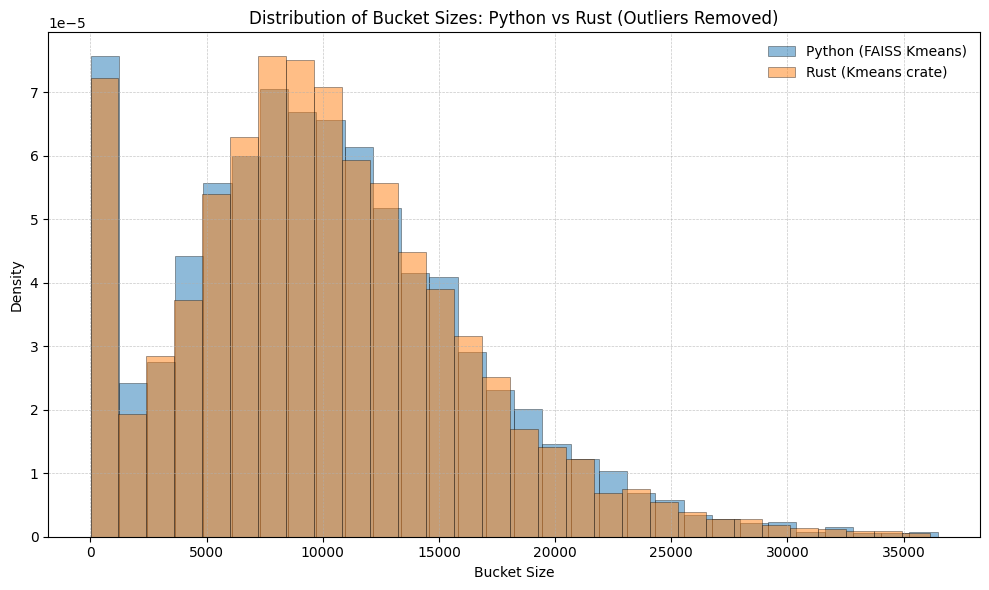

In [7]:
py_bucket_sizes = np.load('py-bucket_sizes-t1-100M.npy')
rs_bucket_sizes = np.load('rs-bucket_sizes-t1-100M.npy')

import matplotlib.pyplot as plt

# Get outliers
py_max = np.max(py_bucket_sizes)
rs_max = np.max(rs_bucket_sizes)
py_min = np.min(py_bucket_sizes)
rs_min = np.min(rs_bucket_sizes)
py_mean = np.mean(py_bucket_sizes)
rs_mean = np.mean(rs_bucket_sizes)
py_median = np.median(py_bucket_sizes)
rs_median = np.median(rs_bucket_sizes)
py_std = np.std(py_bucket_sizes)
rs_std = np.std(rs_bucket_sizes)

print(f"Python: Max={py_max}, Min={py_min}, Mean={py_mean}, Median={py_median}, Std={py_std}")
print(f"Rust: Max={rs_max}, Min={rs_min}, Mean={rs_mean}, Median={rs_median}, Std={rs_std}")


plt.figure(figsize=(10, 6))

plt.hist(py_bucket_sizes, bins=60, density=True, alpha=0.5, label='Python (FAISS Kmeans)', edgecolor='black', linewidth=0.5)
plt.hist(rs_bucket_sizes, bins=60, density=True, alpha=0.5, label='Rust (Kmeans crate)', edgecolor='black', linewidth=0.5)

plt.title("Distribution of Bucket Sizes: Python vs Rust (Outliers Removed)")
plt.xlabel("Bucket Size")
plt.ylabel("Density")
plt.legend(loc='upper right', frameon=False)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

# Remove outliers (more than 3 sd from mean)
py_bucket_sizes = py_bucket_sizes[py_bucket_sizes < py_mean + 4 * py_std]
rs_bucket_sizes = rs_bucket_sizes[rs_bucket_sizes < rs_mean + 4 * rs_std]

# Plot again
plt.figure(figsize=(10, 6))

plt.hist(py_bucket_sizes, bins=30, density=True, alpha=0.5, label='Python (FAISS Kmeans)', edgecolor='black', linewidth=0.5)
plt.hist(rs_bucket_sizes, bins=30, density=True, alpha=0.5, label='Rust (Kmeans crate)', edgecolor='black', linewidth=0.5)

plt.title("Distribution of Bucket Sizes: Python vs Rust (Outliers Removed)")
plt.xlabel("Bucket Size")
plt.ylabel("Density")
plt.legend(loc='upper right', frameon=False)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig("kmeans_benchmark_clean.png", dpi=300, bbox_inches='tight')
plt.show()




In [4]:
import time
import torch
import numpy as np
from pathlib import Path
from math import sqrt
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import faiss
import matplotlib.pyplot as plt

from lmi import LMI
from utils import get_dataset_shape, sample_train_subset

dataset_path = Path('../../data2024/laion2B-en-clip768v2-n=300K.h5')
sample_size = 100_000
chunk_size = 100_000
niter = 3
nsilhouette = 1000
SEED = 42

print(f"--- K-Means Benchmark (Training Data Sample Size: {sample_size}) ---")
n_data_total, data_dim = get_dataset_shape(dataset_path)

X_train_kmeans_full = sample_train_subset(
    dataset_path, n_data_total, data_dim, sample_size, chunk_size
).to(torch.float32)

perm_indices_for_silhouette = None
if nsilhouette is not None and nsilhouette < sample_size:
    actual_silhouette_samples = min(nsilhouette, X_train_kmeans_full.size(0))
    perm_indices_for_silhouette = torch.randperm(X_train_kmeans_full.size(0))[:actual_silhouette_samples]
    X_for_silhouette_eval = X_train_kmeans_full[perm_indices_for_silhouette].cpu().numpy()
    print(f"Using a random subset of {actual_silhouette_samples} samples for Silhouette Score calculation.")
else:
    X_for_silhouette_eval = X_train_kmeans_full.cpu().numpy()
    actual_silhouette_samples = X_train_kmeans_full.size(0)
    print(f"Using all {actual_silhouette_samples} samples for Silhouette Score calculation.")

n_clusters = int(sqrt(sample_size))
if n_clusters == 0:
    raise ValueError(f"Number of clusters cannot be 0. Check KMEANS_TRAIN_SAMPLE_SIZE: {sample_size}")

rs_times, py_times = [], []
rs_silhouette_scores, py_silhouette_scores = [], []
ari_scores, nmi_scores = [], []
py_faiss_internal_objectives = []

for i in range(niter):
    print(f"\n  Iteration {i+1}/{niter}")

    # --- Rust K-Means ---
    start_time_rs = time.time()
    rs_assignments_tensor = LMI._run_kmeans(n_clusters, data_dim, X_train_kmeans_full)
    rs_times.append(time.time() - start_time_rs)
    rs_assignments_np_full = rs_assignments_tensor.cpu().numpy()

    labels_for_silhouette_rs = rs_assignments_np_full
    if perm_indices_for_silhouette is not None:
        labels_for_silhouette_rs = rs_assignments_np_full[perm_indices_for_silhouette.numpy()]

    rs_sil = silhouette_score(X_for_silhouette_eval, labels_for_silhouette_rs, metric='cosine', sample_size=None)
    rs_silhouette_scores.append(rs_sil)
    print(f"    [Rust K-Means]: Time={rs_times[-1]:.3f}s, Silhouette={rs_sil:.4f}")

    # --- Faiss K-Means ---
    start_time_py = time.time()
    kmeans_faiss = faiss.Kmeans(
        d=data_dim, k=n_clusters, verbose=False, spherical=True, niter=25, nredo=1, seed=SEED + i
    )
    X_train_kmeans_np_faiss = X_train_kmeans_full.cpu().numpy()
    kmeans_faiss.train(X_train_kmeans_np_faiss)
    py_times.append(time.time() - start_time_py)
    py_faiss_internal_obj = kmeans_faiss.obj[-1]
    py_faiss_internal_objectives.append(py_faiss_internal_obj)
    py_assignments_np_full = kmeans_faiss.index.search(X_train_kmeans_np_faiss, 1)[1].T[0]

    labels_for_silhouette_py = py_assignments_np_full
    if perm_indices_for_silhouette is not None:
        labels_for_silhouette_py = py_assignments_np_full[perm_indices_for_silhouette.numpy()]

    py_sil = silhouette_score(X_for_silhouette_eval, labels_for_silhouette_py, metric='cosine', sample_size=None)
    py_silhouette_scores.append(py_sil)

    # --- Cluster Similarity Metrics ---
    ari = adjusted_rand_score(rs_assignments_np_full, py_assignments_np_full)
    nmi = normalized_mutual_info_score(rs_assignments_np_full, py_assignments_np_full)
    ari_scores.append(ari)
    nmi_scores.append(nmi)

    print(f"    [Faiss K-Means]: Time={py_times[-1]:.3f}s, Silhouette={py_sil:.4f}, ARI={ari:.4f}, NMI={nmi:.4f} (Faiss Internal Obj={py_faiss_internal_obj:.2f})")

# --- Aggregated Metrics ---
avg_rs_time = np.mean(rs_times)
avg_py_time = np.mean(py_times)
avg_rs_silhouette = np.mean(rs_silhouette_scores)
avg_py_silhouette = np.mean(py_silhouette_scores)
avg_ari = np.mean(ari_scores)
avg_nmi = np.mean(nmi_scores)
avg_py_faiss_internal_obj = np.mean(py_faiss_internal_objectives)

print("\n--- Aggregated K-Means Results ---")
print(f"Training Data Sample Size for K-Means: {sample_size}")
print(f"Silhouette Score evaluated on {actual_silhouette_samples} samples using 'cosine' metric.")
print(f"  Rust (kmeans-crate based):")
print(f"    Avg Time         = {avg_rs_time:.3f}s")
print(f"    Avg Silhouette   = {avg_rs_silhouette:.4f}")
print(f"  Python (Faiss):")
print(f"    Avg Time         = {avg_py_time:.3f}s")
print(f"    Avg Silhouette   = {avg_py_silhouette:.4f}")
print(f"    Avg Faiss Internal Obj = {avg_py_faiss_internal_obj:.2f}")
print(f"  Comparison Metrics:")
print(f"    Avg ARI          = {avg_ari:.4f}")
print(f"    Avg NMI          = {avg_nmi:.4f}")



2025-05-21 18:26:16.916 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.053302s.
2025-05-21 18:26:17.000 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.052648s.


--- K-Means Benchmark (Training Data Sample Size: 100000) ---


2025-05-21 18:26:17.096 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of load_chunk took 0.059099s.
2025-05-21 18:26:17.326 | DEBUG    | utils:wrapper_measure_runtime:30 - Execution of sample_train_subset took 0.46401s.
2025-05-21 18:26:44.116 | DEBUG    | lmi.utils:wrapper_measure_runtime:30 - Execution of _run_kmeans took 26.712s.


Using a random subset of 1000 samples for Silhouette Score calculation.

  Iteration 1/3
    [Rust K-Means]: Time=26.713s, Silhouette=-0.0191


2025-05-21 18:27:23.314 | DEBUG    | lmi.utils:wrapper_measure_runtime:30 - Execution of _run_kmeans took 27.589s.


    [Faiss K-Means]: Time=11.048s, Silhouette=-0.0190, ARI=0.4500, NMI=0.7536 (Faiss Internal Obj=60325.96)

  Iteration 2/3
    [Rust K-Means]: Time=27.590s, Silhouette=-0.0191


2025-05-21 18:28:03.410 | DEBUG    | lmi.utils:wrapper_measure_runtime:30 - Execution of _run_kmeans took 27.331s.


    [Faiss K-Means]: Time=12.175s, Silhouette=-0.0274, ARI=0.4394, NMI=0.7569 (Faiss Internal Obj=60336.97)

  Iteration 3/3
    [Rust K-Means]: Time=27.332s, Silhouette=-0.0191
    [Faiss K-Means]: Time=13.513s, Silhouette=-0.0183, ARI=0.4786, NMI=0.7662 (Faiss Internal Obj=60348.28)

--- Aggregated K-Means Results ---
Training Data Sample Size for K-Means: 100000
Silhouette Score evaluated on 1000 samples using 'cosine' metric.
  Rust (kmeans-crate based):
    Avg Time         = 27.212s
    Avg Silhouette   = -0.0191
  Python (Faiss):
    Avg Time         = 12.245s
    Avg Silhouette   = -0.0216
    Avg Faiss Internal Obj = 60337.07
  Comparison Metrics:
    Avg ARI          = 0.4560
    Avg NMI          = 0.7589


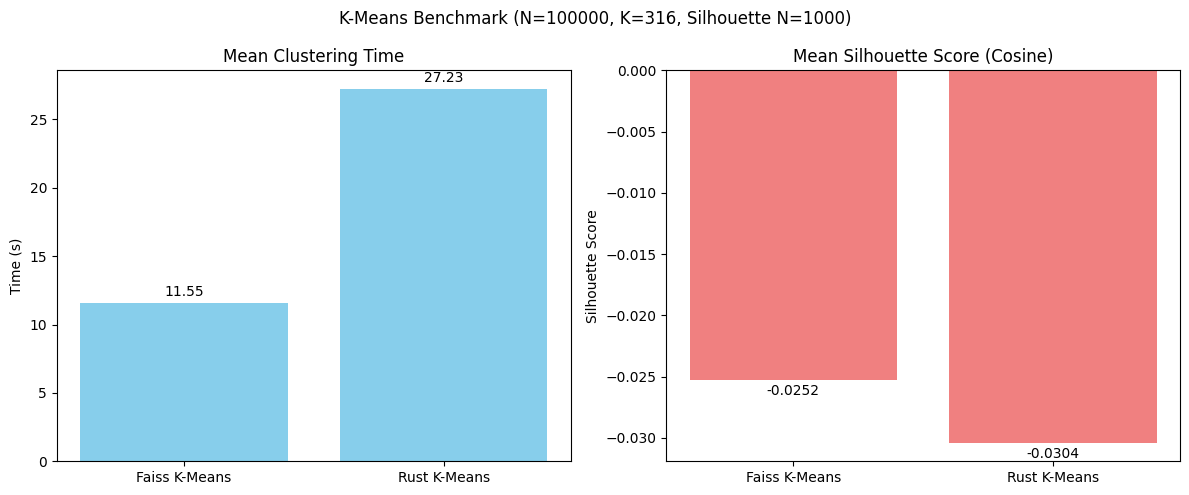

In [3]:
# --- Plot: Time and Silhouette ---
labels_plot = ['Faiss K-Means', 'Rust K-Means']
times_plot = [avg_py_time, avg_rs_time]
silhouette_scores_plot = [avg_py_silhouette, avg_rs_silhouette]

x_indices = np.arange(len(labels_plot))
bar_width = 0.30

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Time Plot
axs[0].bar(labels_plot, times_plot, color='skyblue')
axs[0].set_title('Mean Clustering Time')
axs[0].set_ylabel('Time (s)')
axs[0].bar_label(axs[0].containers[0], fmt='%.2f', padding=3)

# Silhouette Plot
axs[1].bar(labels_plot, silhouette_scores_plot, color='lightcoral')
axs[1].set_title('Mean Silhouette Score (Cosine)')
axs[1].set_ylabel('Silhouette Score')
axs[1].bar_label(axs[1].containers[0], fmt='%.4f', padding=3)

plt.suptitle(f'K-Means Benchmark (N={sample_size}, K={n_clusters}, Silhouette N={actual_silhouette_samples})')
plt.tight_layout()
plt.savefig("kmeans_benchmark_clean.png")
plt.show()
